In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [9]:
print(nav.shape)

print(performance.shape)

print(transactions.shape)

print(portfolio.shape)

(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

results = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_report = pd.DataFrame(results)

In [11]:
risk_report = risk_report.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_report = risk_report[
    ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
]

risk_report.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [12]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


In [13]:
key_funds = [
    119551,   # SBI Bluechip
    120503,   # ICICI Bluechip
    118632,   # Nippon Large Cap
    119092,   # Axis Bluechip
    120841    # Kotak Bluechip
]

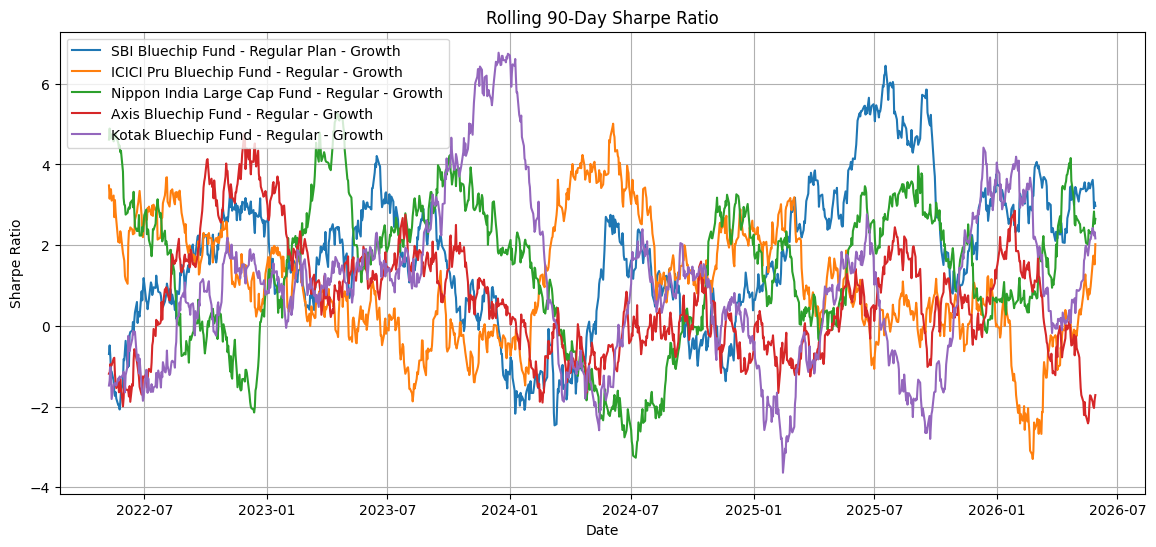

In [14]:
plt.figure(figsize=(14,6))

for fund in key_funds:

    df = nav[nav["amfi_code"] == fund].copy()

    rolling_sharpe = (
        df["daily_return"].rolling(90).mean()
        /
        df["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    name = performance.loc[
        performance["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(df["date"], rolling_sharpe, label=name)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

In [15]:
plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

first_year = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
)

transactions = transactions.merge(
    first_year.rename("cohort"),
    on="investor_id"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
cohort_stats = (
    transactions
    .groupby("cohort")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_stats

,cohort,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [18]:
transactions = transactions.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [19]:
top_funds = (
    transactions
    .groupby(["cohort", "scheme_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["cohort", "count"], ascending=[True, False])
    .drop_duplicates("cohort")
)

top_funds

,cohort,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [20]:
cohort_report = cohort_stats.merge(
    top_funds[["cohort", "scheme_name"]],
    on="cohort"
)

cohort_report

,cohort,avg_sip_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [21]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully.")

cohort_analysis.csv saved successfully.


In [22]:
sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth


In [23]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,Axis Midcap Fund - Regular - Growth,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,ABSL Small Cap Fund - Regular - Growth,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,DSP Top 100 Equity Fund - Regular - Growth,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0


In [24]:
sip_summary = (
    sip.groupby("investor_id")
       .agg(
           sip_count=("transaction_date", "count"),
           avg_gap_days=("gap_days", "mean")
       )
       .reset_index()
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [25]:
sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary["status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

sip_summary

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk
...,...,...,...,...
4746,INV004984,7,75.333333,At-Risk
4748,INV004986,7,81.333333,At-Risk
4754,INV004992,7,81.500000,At-Risk
4758,INV004996,10,46.333333,At-Risk


In [26]:
sip_summary.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("sip_continuity_analysis.csv saved successfully.")

sip_continuity_analysis.csv saved successfully.


In [27]:
portfolio["weight"] = portfolio["weight_pct"] / 100

sector_hhi = (
    portfolio
    .groupby(["amfi_code", "sector"])["weight"]
    .sum()
    .reset_index()
)

sector_hhi.head()

,amfi_code,sector,weight
0,100016,Automobile,0.1484
1,100016,Banking,0.0339
2,100016,Energy,0.0609
3,100016,FMCG,0.1168
4,100016,IT,0.2590


In [28]:
hhi = (
    sector_hhi
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [29]:
hhi = hhi.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi = hhi[
    ["amfi_code", "scheme_name", "HHI"]
]

hhi.head()

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.180588
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.180042
3,101207,ABSL Small Cap Fund - Regular - Growth,0.222727
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.180712


In [30]:
hhi["Concentration"] = np.where(
    hhi["HHI"] > 0.20,
    "Highly Concentrated",
    np.where(
        hhi["HHI"] > 0.10,
        "Moderately Concentrated",
        "Diversified"
    )
)

hhi

,amfi_code,scheme_name,HHI,Concentration
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.180588,Moderately Concentrated
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647,Highly Concentrated
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.180042,Moderately Concentrated
3,101207,ABSL Small Cap Fund - Regular - Growth,0.222727,Highly Concentrated
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.180712,Moderately Concentrated
5,102886,UTI Mid Cap Fund - Regular - Growth,0.124020,Moderately Concentrated
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383,Highly Concentrated
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.207259,Highly Concentrated
8,118633,Nippon India Large Cap Fund - Direct - Growth,0.221200,Highly Concentrated
9,118634,Nippon India Small Cap Fund - Regular - Growth,0.160299,Moderately Concentrated


In [31]:
hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

print("sector_hhi_report.csv saved successfully.")

sector_hhi_report.csv saved successfully.


# Advanced Insights

1. Historical VaR and CVaR analysis shows that some equity funds have significantly larger downside risk, indicating higher exposure to adverse market movements.

2. The Rolling 90-Day Sharpe Ratio demonstrates that the selected large-cap funds experience changing risk-adjusted performance over time, with periods of stronger and weaker efficiency.

3. Investor cohort analysis indicates differences in average investment amounts and preferred funds across cohorts, reflecting evolving investor behavior over time.

4. SIP continuity analysis identified investors with six or more SIP transactions whose average payment gap exceeded 35 days, classifying them as "At-Risk" and highlighting potential SIP discontinuation.

5. Sector HHI analysis shows varying levels of portfolio concentration across funds. Funds with higher HHI values are more concentrated in fewer sectors, while lower HHI values indicate better sector diversification.